In [18]:
from dataloader import build_loaders
from model import build_model

# IMPORTANT: Samples=5 (the 5 frequency bands), not 200
model = build_model(nb_classes=4, Chans=62, Samples=5)


In [19]:
train_loader, val_loader = build_loaders(
    data_root   = '/fs/vulcan-projects/fsh_track/jason-bhargav-temp/CMSC472-Final/data',
    val_subject = 1,
    dataset     = 'SEED-IV',
    window_sec  = 1.0,
    sfreq       = 200,
    n_per_class = 8,
)


Building loaders  [cross_subject]  dataset=SEED-IV  feature=de_LDS
  Loading subject 01/15 … 2505 windows
  Loading subject 02/15 … 2505 windows
  Loading subject 03/15 … 2505 windows
  Loading subject 04/15 … 2505 windows
  Loading subject 05/15 … 2505 windows
  Loading subject 06/15 … 2505 windows
  Loading subject 07/15 … 2505 windows
  Loading subject 08/15 … 2505 windows
  Loading subject 09/15 … 2505 windows
  Loading subject 10/15 … 2505 windows
  Loading subject 11/15 … 2505 windows
  Loading subject 12/15 … 2505 windows
  Loading subject 13/15 … 2505 windows
  Loading subject 14/15 … 2505 windows
  Loading subject 15/15 … 2505 windows

  Train : (35070, 62, 5)  labels [9492 9562 8610 7406]
  Val   : (2505, 62, 5)  labels [678 683 615 529]

  Batch size    : 32  (8/class × 4 classes)
  Train batches : 925
  Val   batches : 79



In [20]:
import torch
from model import build_model, EEGDataset, BalancedBatchSampler, Trainer
from losses import ClassificationLoss, ContrastiveLoss

model     = build_model(nb_classes=4, Chans=62, Samples=5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

trainer = Trainer(
    model, ClassificationLoss(), ContrastiveLoss(temperature=0.1),
    optimizer, lambda_con=0.5, warmup_epochs=5, device='cuda'
)
history = trainer.fit(train_loader, val_loader, epochs=50)

Epoch 001/50  train_loss=3.4537  cls=0.0000  con=3.4537  acc=0.251  |  val_loss=3.4238  val_acc=0.211
Epoch 002/50  train_loss=3.4336  cls=0.0000  con=3.4336  acc=0.254  |  val_loss=3.4274  val_acc=0.211
Epoch 003/50  train_loss=3.4292  cls=0.0000  con=3.4292  acc=0.254  |  val_loss=3.4243  val_acc=0.289
Epoch 004/50  train_loss=3.4238  cls=0.0000  con=3.4238  acc=0.259  |  val_loss=3.4249  val_acc=0.190
Epoch 005/50  train_loss=2.9830  cls=1.2765  con=3.4132  acc=0.393  |  val_loss=3.1694  val_acc=0.324
Epoch 006/50  train_loss=2.9188  cls=1.2183  con=3.4010  acc=0.438  |  val_loss=3.0679  val_acc=0.416
Epoch 007/50  train_loss=2.8749  cls=1.1797  con=3.3903  acc=0.465  |  val_loss=3.0185  val_acc=0.327
Epoch 008/50  train_loss=2.8616  cls=1.1696  con=3.3840  acc=0.470  |  val_loss=3.0301  val_acc=0.402
Epoch 009/50  train_loss=2.8398  cls=1.1510  con=3.3777  acc=0.483  |  val_loss=2.9944  val_acc=0.388
Epoch 010/50  train_loss=2.8240  cls=1.1383  con=3.3714  acc=0.487  |  val_loss=3.

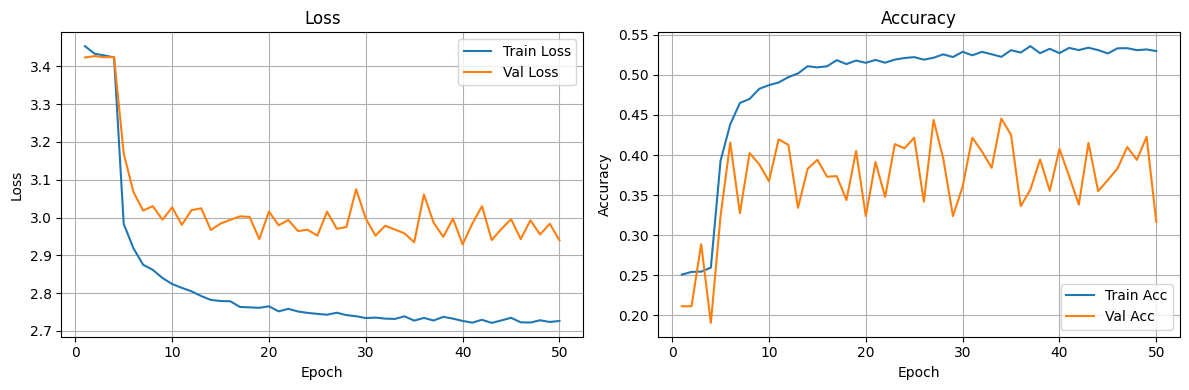

In [21]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train']) + 1)

    train_loss = [e['loss'] for e in history['train']]
    val_loss   = [e['loss'] for e in history['val']]
    train_acc  = [e['acc']  for e in history['train']]
    val_acc    = [e['acc']  for e in history['val']]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    ax1.plot(epochs, train_loss, label='Train Loss')
    ax1.plot(epochs, val_loss,   label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy
    ax2.plot(epochs, train_acc, label='Train Acc')
    ax2.plot(epochs, val_acc,   label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('checkpoints/training_curves.png', dpi=150)
    plt.show()

plot_history(history)


In [22]:
import os

# Save
save_path = 'checkpoints/ContrastiveLoss_0.1.pt'
os.makedirs('checkpoints', exist_ok=True)

torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history'             : history,
}, save_path)

print(f"Model saved to {save_path}")


Model saved to checkpoints/ContrastiveLoss_0.1.pt


In [ ]:
checkpoint = torch.load('checkpoints/eegnet_seediv.pt', map_location='cuda')

model = build_model(nb_classes=4, Chans=62, Samples=5)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()